In [1]:
%load_ext autoreload
%autoreload 2

In [3]:
DATA_DIR="/data/group_data/rl/datasets/redteaming"

In [24]:
import numpy as np
import pandas as pd
from redteam.train.train_rwr import DataArguments
from redteam.train.dataset_utils import RWRDatasetHelper
from redteam.utils.data_utils import read_json


In [9]:
data_args = DataArguments(
    data_path=f"{DATA_DIR}/gen_judge_multiturn_conversation_combined/combined_train_data_llama_rewards_flat_length_added.json",
    eval_data_path=f"{DATA_DIR}/gen_judge_multiturn_conversation_combined/combined_eval_data_llama_rewards_flat_length_added.json",
    agent_type="defender",
    gamma=0.9,
    dataset_type="naive_balance",
    length_key="Meta-Llama-3.1-8B-Instruct_length",
    max_length=4096,
    value_function_type=None,
    model_name="meta-llama/Meta-Llama-3.1-8B-Instruct",
    value_function_experiment=None,
)

In [10]:
dataset_helper = RWRDatasetHelper(
        data_args.data_path,
        data_args.agent_type,
        dataset_type=data_args.dataset_type,
        length_key=data_args.length_key,
        max_length=data_args.max_length,
    )

In [21]:
train_dataset = read_json(f"{DATA_DIR}/gen_judge_multiturn_conversation_combined/combined_train_data_llama_rewards_flat_length_added.json")



In [25]:
raw_data = pd.DataFrame(train_dataset)
raw_data["rewards"] = raw_data["rewards"].apply(lambda x: np.array(x))

In [19]:
dataset_helper.raw_data.rewards

0        [1.0, 1.0, 0.0]
1        [1.0, 0.0, 1.0]
2        [1.0, 1.0, 0.0]
3        [1.0, 1.0, 1.0]
4        [1.0, 1.0, 1.0]
              ...       
16435    [1.0, 1.0, 1.0]
16436    [1.0, 1.0, 1.0]
16437    [1.0, 1.0, 1.0]
16438    [1.0, 1.0, 1.0]
16439    [1.0, 1.0, 1.0]
Name: rewards, Length: 16440, dtype: object

In [34]:
dataset_helper.raw_data.positives.sum()

12531

In [36]:
12531/16439

0.7622726443214307

In [32]:
raw_data["rewards"]

0        [0.0, 0.0, 1.0]
1        [0.0, 1.0, 0.0]
2        [0.0, 0.0, 1.0]
3        [0.0, 0.0, 0.0]
4        [0.0, 0.0, 0.0]
              ...       
16435    [0.0, 0.0, 0.0]
16436    [0.0, 0.0, 0.0]
16437    [0.0, 0.0, 0.0]
16438    [0.0, 0.0, 0.0]
16439    [0.0, 0.0, 0.0]
Name: rewards, Length: 16440, dtype: object

In [37]:
attacker_dataset_helper = RWRDatasetHelper(
        data_args.data_path,
        "attacker",
        dataset_type=data_args.dataset_type,
        length_key=data_args.length_key,
        max_length=data_args.max_length,
    )

In [38]:
attacker_dataset_helper.raw_data.positives.sum()

3909

In [39]:
3909 + 12531

16440

In [40]:
raw_data["rewards"].apply(tuple).value_counts()

rewards
(0.0, 0.0, 0.0)    12531
(0.0, 0.0, 1.0)     2115
(0.0, 1.0, 1.0)      731
(0.0, 1.0, 0.0)      504
(1.0, 1.0, 1.0)      266
(1.0, 0.0, 1.0)      127
(1.0, 0.0, 0.0)      110
(1.0, 1.0, 0.0)       56
Name: count, dtype: int64

In [41]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_rewards_histogram(df: pd.DataFrame, column_name: str):
    # Get value counts
    value_counts = df[column_name].apply(tuple).value_counts()
    
    # Create horizontal bar plot
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Plot bars
    bars = ax.barh(value_counts.index.astype(str), value_counts.values, align='center')
    
    # Customize the plot
    ax.set_ylabel('Reward Combinations')
    ax.set_xlabel('Count')
    ax.set_title(f'Distribution of {column_name.capitalize()} Combinations')
    
    # Add count labels to the end of each bar
    for bar in bars:
        width = bar.get_width()
        ax.text(width, bar.get_y() + bar.get_height()/2, f'{width}', 
                ha='left', va='center', fontweight='bold')
    
    # Adjust layout and display
    plt.tight_layout()
    plt.show()

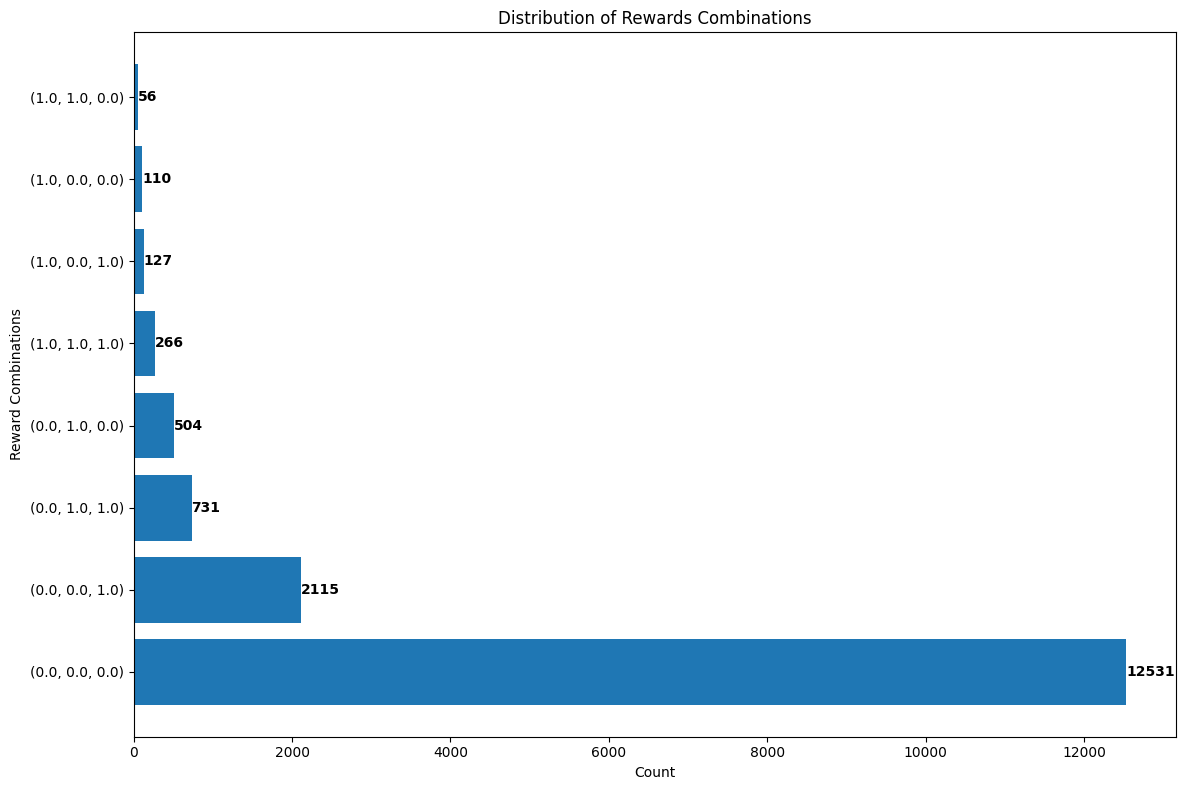

In [42]:
plot_rewards_histogram(raw_data, "rewards")

In [51]:
(raw_data["Meta-Llama-3.1-8B-Instruct_length"]>4096).sum()

4

In [55]:
(raw_data["Mistral-7B-Instruct-v0.1_length"]>4096).sum()

24

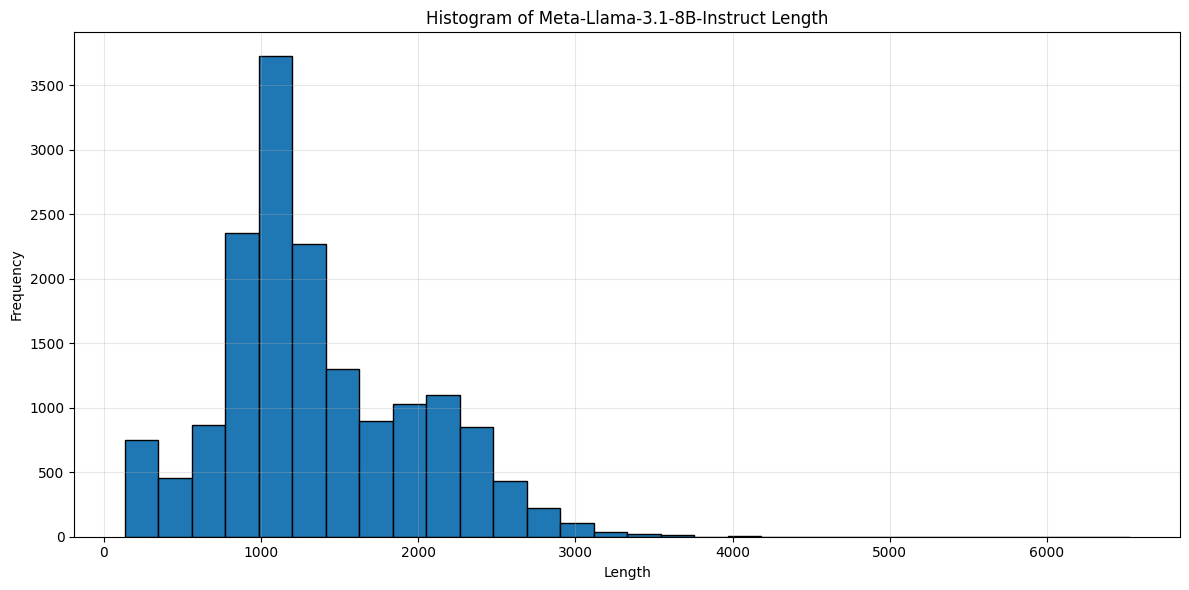

In [47]:
plt.figure(figsize=(12, 6))
plt.hist(raw_data["Meta-Llama-3.1-8B-Instruct_length"], bins=30, edgecolor='black')
plt.title("Histogram of Meta-Llama-3.1-8B-Instruct Length")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [52]:
raw_data.keys()

Index(['goal', 'category', 'conversation', 'rewards', 'generation_model',
       'gpt4_safety_label', 'gpt4_reasoning', 'gpt4_goal_achieved',
       'Mistral-7B-Instruct-v0.1_length', 'Meta-Llama-3.1-8B-Instruct_length'],
      dtype='object')